# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab, to understand the following.

# Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

# Replicate the Exploratory Data Analysis (EDA)

First we import the necessary Python libraries and turn off warning messages so the output is cleaner.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from datetime import datetime

Now we load the dataset from the URL:
1. download the CSV file from GitHub
2. read it into a pandas DataFrame called `raw_data`
3. `len(raw_data)` gives the number of rows (same as `nrow(raw_data)` in R)

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

raw_data = pd.read_csv(url)
len(raw_data)

7214

The command `raw_data.head(10)` shows the first 10 rows of the dataset so we can preview and ensure it was loaded successfully.

In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

The next block of code replaces previous R pipelines to:
1. define which variables are numerical or dates
2. select columns
3. filter rows
4. create additional categorical columns and map values
5. count the number of rows after filtering

In [ ]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Fix: Define base_columns as a list, not a subsetted DataFrame
base_columns = ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text',
                'sex', 'priors_count', 'days_b_screening_arrest',
                'decile_score', 'is_recid', 'two_year_recid',
                'c_jail_in', 'c_jail_out']

df = raw_data[base_columns].copy()

df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid" ] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].astype("category")
df["race_factor"] = df["race"].astype("category")

# Map sex to Female/Male labels
df["gender_factor"] = df["sex"].replace({"F": "Female", "M": "Male"}).astype("category")

# Map scores to LowScore/HighScore labels
df["score_factor"] = "HighScore"
df.loc[df["score_text"] == "Low", "score_factor"] = "LowScore"
df["score_factor"] = df["score_factor"].astype("category")

len(df)

6172

The number of rows in the dataset has decreased from 7214 to 6172 after removing `days_b_screening_arrest` more than 30 days apart, defendants who were not re-arrested `is_recid != -1`, those with a `charge_degree` of zero, and the rows where the `score_text` was not available.

In [ ]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34,2014-03-18 04:28:46,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06,2013-11-26 08:26:57,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35,2013-10-07 08:17:30,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03,2013-01-02 01:12:19,M,25 - 45,Caucasian,Female,LowScore


In [ ]:
df.info(10)

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      6172 non-null   int64   
 1   c_charge_degree          6172 non-null   object  
 2   race                     6172 non-null   object  
 3   age_cat                  6172 non-null   object  
 4   score_text               6172 non-null   object  
 5   sex                      6172 non-null   object  
 6   priors_count             6172 non-null   int64   
 7   days_b_screening_arrest  6172 non-null   float64 
 8   decile_score             6172 non-null   int64   
 9   is_recid                 6172 non-null   int64   
 10  two_year_recid           6172 non-null   int64   
 11  c_jail_in                6172 non-null   object  
 12  c_jail_out               6172 non-null   object  
 13  crime_factor             6172 non-null   category
 14  age_factor   

The next block of code:
1. converts the date columns to actual datetime objects
2. calculates the number of days spent in jail: subtract the dates to extract the number of days
3. calculates the correlation between stay length and COMPAS score

In [ ]:
df['c_jail_in'] = pd.to_datetime(df['c_jail_in'])
df['c_jail_out'] = pd.to_datetime(df['c_jail_out'])

df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

correlation = df['length_of_stay'].corr(df['decile_score'])
print(f"Correlation: {correlation}")

# Interpretation:
# A correlation of 0.207 is considered a weak positive correlation.
# It suggests that higher COMPAS scores are associated with slightly longer
# jail stays, but the low value indicates that score alone is a poor
# predictor of how long someone will remain in custody.

Correlation: 0.20747808478031807


A correlation of 0.207 indiactes a weak positive relationship between
an individual's COMPAS score and the length of time they are in jail. While the algorithm has some alignment with the length of the stay, there are many factors that influence the length of stay, but are not captured in the COMPAS algorithm.

Higher COMPAS scores are slightly correlated with a longer length of stay.

After filtering we have the following demographic breakdown:

In [ ]:
print("Summary of Age Categories:")
df['age_cat'].value_counts()

Summary of Age Categories:


,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


The majority of individuals are in the age range 25-45. This may affect the reliability of the algorithm for individuals outside of that age range, with fewer data points on which to train and test the model.

In [ ]:
print("\nSummary of Race:")
df['race'].value_counts()


Summary of Race:


,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


This calculates and prints the percentage of defendants for each racial group to show their relative representation in the filtered data:

In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


The majority of individuals are identified as African-American, by a wide margin: Black defendants make up more than half of the data set, with individuals identified as a race other than Black or White making up less than 15% of the dataset. This may affect the reliability of the algorithm for individuals identified as other races, with fewer data points on which to train and test the model. This may also cause the model to more heavily weight race as a predictive factor.

In [ ]:
print("Summary of Score Text:")
df['score_text'].value_counts()

Summary of Score Text:


,count
score_text,
Low,3421
Medium,1607
High,1144


Over 55% of individuals in the dataset are categorized as "low" risk of recidivism; individuals categorized as "high" risk make up less than 20% of the dataset. This may also skew the model.

In [ ]:
table = pd.crosstab(df['sex'], df['race'])
print("Table of Sex vs Race:")
table

Table of Sex vs Race:


race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


Based on this breakdown, we might expect the model to most accurately predict the recidivism rate of Males identified as African-American and then Caucasian - though this may make the model disproportionately identify those groups as likely to re-offend.

In [ ]:
print("Summary of Gender:")
df['sex'].value_counts()

Summary of Gender:


,count
sex,
Male,4997
Female,1175


In [ ]:
# This calculates the demographic proportion of the dataset
men_count = len(df[df['sex'] == 'Male'])
women_count = len(df[df['sex'] == 'Female'])
total_count = len(df)

print("Percentage of dataset categorized as Male: %.2f%%" % (men_count / total_count * 100))
print("Percentage of dataset categorized as Female: %.2f%%" % (women_count / total_count * 100))

Percentage of dataset categorized as Male: 80.96%
Percentage of dataset categorized as Female: 19.04%


In [ ]:
recid_count = len(df[df['two_year_recid'] == 1])
print(f"Number of recidivists within two years: {recid_count}")

Number of recidivists within two years: 2809


This calculates the overall recidivism rate for the entire cohort over the two-year period:

In [ ]:
recid_rate = (len(df[df['two_year_recid'] == 1]) / len(df)) * 100
print("Overall two-year recidivism rate: %.2f%%" % recid_rate)

Overall two-year recidivism rate: 45.51%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

## Plotting potential racial disparities
Visualizations are helpful in analyzing data. This next block of code uses seaborn to create two count plots of decile scores: one for African-American defendants and one for Caucasian defendants. This allows comparison of the distributions for Black and White defendants side-by-side to visualize potential disparities in COMPAS scoring.

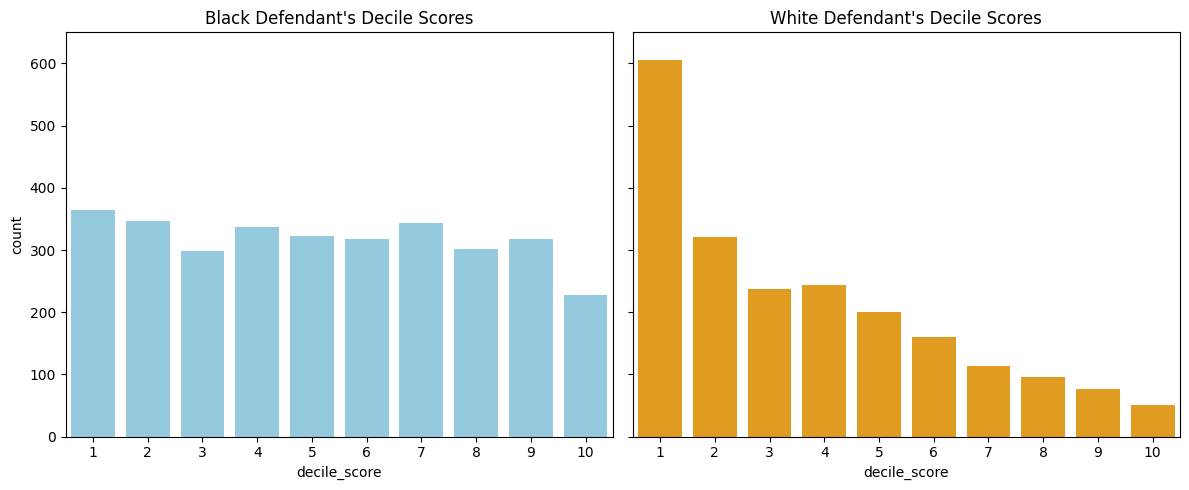

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.countplot(data=df[df['race'] == 'African-American'], x='decile_score', ax=axes[0], color='skyblue')
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)

sns.countplot(data=df[df['race'] == 'Caucasian'], x='decile_score', ax=axes[1], color='orange')
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

Display the exact counts in a table (Python `xtabs` equivalent)

In [ ]:
cross_tab = pd.crosstab(df['decile_score'], df['race'])
print("Decile Score counts by Race:")
cross_tab

Decile Score counts by Race:


race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


The plots and table reveal a wide disparity: Caucasian defendants are disproportionately assigned a low decile score, with nearly twice as many Caucasian defendants scored "1" than African-American defendants, and nearly five times as many African-American defendants scored "10" than Caucasian defendants.

# Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

The next block of code:
1. imports a few more python libraries
2. ensures the dependent variable, the score factor, is numeric (and not empty)
3. fits the logistic regression model
4. calculates and prints the additional metrics

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Map the target variable to numeric (0 for Low, 1 for High)
df['score_factor_numeric'] = df['score_factor'].map({'LowScore': 0, 'HighScore': 1}).astype(int)

# We define a formula to see how gender, age, race, priors, and actual recidivism affect the score
formula = "score_factor_numeric ~ C(gender_factor, Treatment('Male')) + " \
          "C(age_factor, Treatment('25 - 45')) + " \
          "C(race_factor, Treatment('Caucasian')) + " \
          "priors_count + crime_factor + two_year_recid"

model = smf.logit(formula=formula, data=df).fit()
print(model.summary())

# Calculate fit metrics: Deviance and AIC
null_deviance = -2 * model.llnull
residual_deviance = -2 * model.llf
aic = model.aic
fisher_iterations = model.mle_retvals['iterations']

print(f"Null deviance: {null_deviance:.1f} on {model.df_model + model.df_resid} degrees of freedom")
print(f"Residual deviance: {residual_deviance:.1f} on {model.df_resid} degrees of freedom")
print(f"AIC: {aic:.1f}")
print(f"Number of Fisher Scoring iterations: {fisher_iterations}")

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     score_factor_numeric   No. Observations:                 6172
Model:                            Logit   Df Residuals:                     6160
Method:                             MLE   Df Model:                           11
Date:                  Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                          10:52:07   Log-Likelihood:                -3084.2
converged:                         True   LL-Null:                       -4241.7
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------

The table above indicates how different factors (age, race, etc) affect whether someone gets a 'High Risk' score. The coefficients show direction (up or down) and strength (a little or a lot) of the effect.

The p-value indicates that the results are statistically significant and the eta-squared indicates our model explains about 27% of the variance in the model. 27% is a fairly adequate amount of human behavior for a model to explain, but indicates there are other factors not captured in the algorithm. With a residual deviance much lower than the null deviance, we can conclude the adding the factors listed in the table made the model more accurate.

Take a closer look: defendants under 25 years of age and Native American defendants have coefficients of 1.31 and 1.39 respectively, indicating they are flagged as "high" risk more often than other groups. Conversely, Caucasian defendants have a coefficient of -1.53 and defendants over age 45 have a coefficient of -1.36, indicating they are flagged as "high" risk less often than other groups.

When we recall that only 0.18% of our dataset is comprised of Native American defendants, this increases skepticism of the accuracy of the model on the demographics that were not substantially represented in the training data.

The code in this block:
1. extracts the intercept (baseline risk) and  specific coefficient for African-American defendants
2. calculates the control value, which represents the average risk for the baseline group (Caucasian defendants)
3. converts logarithmic coefficient into a human-readable multiplier

In [ ]:
import math

intercept = model.params['Intercept']
coeff_black = model.params["C(race_factor, Treatment('Caucasian'))[T.African-American]"]

control = math.exp(intercept) / (1 + math.exp(intercept))
multiplier = math.exp(coeff_black) / (1 - control + (control * math.exp(coeff_black)))
print(f"Black defendants likelihood multiplier: {multiplier:.3f}")

Black defendants likelihood multiplier: 1.453


Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

The code in this block uses the control value above and:
1. extracts the coefficient for Female gender
2. calculates the likelihood multiplier for women


In [ ]:
coeff_female = model.params["C(gender_factor, Treatment('Male'))[T.Female]"]

gender_multiplier = math.exp(coeff_female) / (1 - control + (control * math.exp(coeff_female)))
print(f"Women likelihood multiplier: {gender_multiplier:.3f}")

Women likelihood multiplier: 1.195


Women are 19.5% more likely than men to get a higher score.

When we recall that women comprise less than 20% of the training data, this may explain why they are more likely to be scored higher - more training data on women is needed to create a more accurate model.

The code in this block uses the control value above and:
1. extracts the coefficient for defendants age < 25
2. calculates the likelihood multiplier for young defendants


In [ ]:
coeff_young = model.params["C(age_factor, Treatment('25 - 45'))[T.Less than 25]"]

age_multiplier = math.exp(coeff_young) / (1 - control + (control * math.exp(coeff_young)))
print(f"Defendants under age 25 likelihood multiplier: {age_multiplier:.3f}")

Defendants under age 25 likelihood multiplier: 2.496


Most surprisingly, people under 25 are nearly 2.5 times as likely to get a higher score as middle aged defendants. This matches the output of the logit regression, so we can be confident in our math. As mentioned before, young people are underrepresented in the data and the model may need training on more data from young defendants to improve accuracy.

# Risk of Violent Recidivism

Compas also offers a score that aims to measure a person's risk of violent recidivism, which has a similar overall accuracy to the recidivism score. As before, we can use a logistic regression to test for racial bias.

In [ ]:
# Load the violent recidivism dataset
url_violent = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv"
raw_data_violent = pd.read_csv(url_violent)
print(f"Number of rows in violent data: {len(raw_data_violent)}")

Number of rows in violent data: 4743


In [ ]:
# Select columns and filter rows for violent recidivism analysis
df_violent = raw_data_violent[[
    'age', 'c_charge_degree', 'race', 'age_cat', 'v_score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'v_decile_score', 'is_recid', 'two_year_recid'
]].copy()

df_violent = df_violent[
    (df_violent['days_b_screening_arrest'] <= 30) &
    (df_violent['days_b_screening_arrest'] >= -30) &
    (df_violent['is_recid'] != -1) &
    (df_violent['c_charge_degree'] != "O") &
    (df_violent['v_score_text'] != 'N/A')
]
print(f"Rows after filtering: {len(df_violent)}")

Rows after filtering: 4020


The number of rows in the dataset has decreased from 4743 to 4020 after removing `days_b_screening_arrest` more than 30 days apart, defendants who `is_recid != -1`, those with a `charge_degree` of zero, and the rows where the `score_text` was not available.

In [ ]:
df_violent["age_cat"].value_counts()

,count
age_cat,
25 - 45,2300
Greater than 45,954
Less than 25,766


Again we see defendants aged 25-45 overrepresented in the data - more than half.

In [ ]:
df_violent["race"].value_counts()

,count
race,
African-American,1918
Caucasian,1459
Hispanic,355
Other,255
Asian,26
Native American,7


Again we see African-American	defendants overrepresented in the data - about 48%.

In [ ]:
df_violent["v_score_text"].value_counts()

,count
v_score_text,
Low,2913
Medium,828
High,279


The violent recidivism dataset is comprised of </br>
   72% low</br>
   21% medium</br>
   7% high</br>
scores. With the data weighted towards lower scores, we would expect the model to be less accurate in predicting higher decile scores.

In [ ]:
len(df_violent[df_violent['two_year_recid'] == 1])

652

In [ ]:
violent_recid_rate = len(df_violent[df_violent["two_year_recid"] == 1]) / len(df_violent) * 100
print(f"Overall violent recidivism rate: {violent_recid_rate:.2f}%")

Overall violent recidivism rate: 16.22%


In this filtered dataset 652 individuals (16.22%) committed a violent crime within the two-year follow-up period.

## Plotting potential disparities in violent crime
This next block of code uses seaborn to create two count plots of decile scores in the violent crime data: one for African-American defendants and one for Caucasian defendants. Again, this allows side-by-side comparison of the distributions to visualize potential disparities in COMPAS scoring.

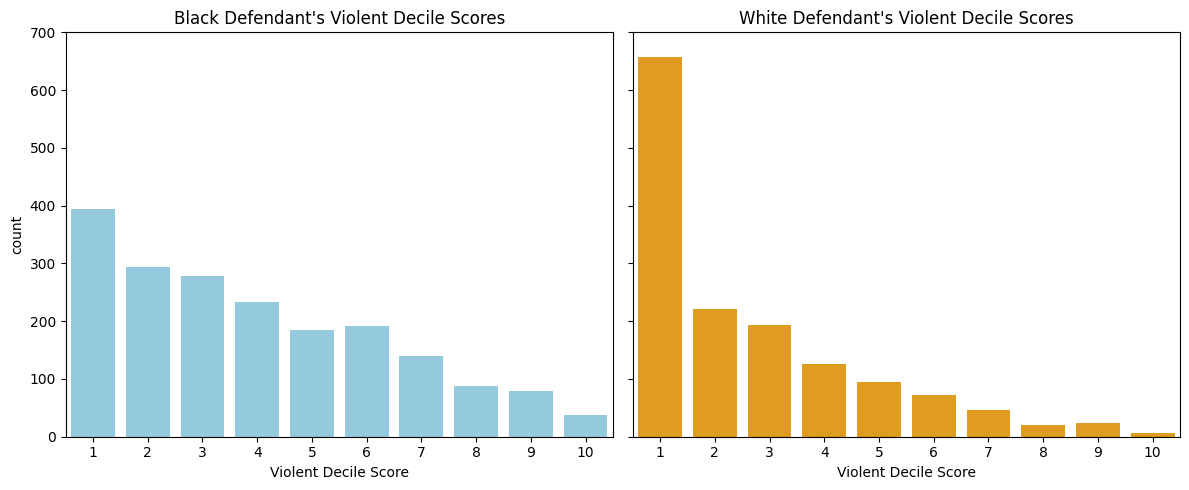

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a side-by-side plot for Violent Decile Scores
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for Black defendants
sns.countplot(data=df_violent[df_violent['race'] == 'African-American'], x='v_decile_score', ax=axes[0], color='skyblue')
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Violent Decile Score")
axes[0].set_ylim(0, 700)

# Plot for White defendants
sns.countplot(data=df_violent[df_violent['race'] == 'Caucasian'], x='v_decile_score', ax=axes[1], color='orange')
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Violent Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

The plots and table again reveal a wide disparity: Caucasian defendants are disproportionately assigned a low decile score, with many more Caucasian defendants scored "1" than Black defendants, and Caucasian defendants scored "10" at a fraction of the rate of Black defendants.

In [ ]:
# Map score_factor to numeric for the violent model (LowScore=0, HighScore=1)
df_violent['score_factor_numeric'] = (df_violent['v_score_text'] != 'Low').astype(int)

import statsmodels.formula.api as smf

formula_v = "score_factor_numeric ~ C(sex, Treatment('Male')) + " \
            "C(age_cat, Treatment('25 - 45')) + " \
            "C(race, Treatment('Caucasian')) + " \
            "priors_count + c_charge_degree + two_year_recid"

model_v = smf.logit(formula=formula_v, data=df_violent).fit()
print(model_v.summary())

Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7
                            Logit Regression Results                            
Dep. Variable:     score_factor_numeric   No. Observations:                 4020
Model:                            Logit   Df Residuals:                     4008
Method:                             MLE   Df Model:                           11
Date:                  Mon, 30 Mar 2026   Pseudo R-squ.:                  0.3662
Time:                          10:52:08   Log-Likelihood:                -1499.4
converged:                         True   LL-Null:                       -2365.9
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept 

The table above indicates how different factors (age, race, etc) affect whether someone gets a 'High Risk' score. The coefficients show direction (up or down) and strength (a little or a lot) of the effect.

The p-value indicates that the results are statistically significant and the eta-squared indicates our model explains about 37% of the variance in the model. 37% is a fairly adequate amount of human behavior for a model to explain - and better than our previous model, but indicates there are other factors not captured in the algorithm.

 With a residual deviance much lower than the null deviance, we can conclude the adding the factors listed in the table made the model more accurate, improved the "fit".

In [ ]:
import math

# Calculate likelihood multiplier for Black defendants (Violent Score)
intercept_v = model_v.params['Intercept']
coeff_black_v = model_v.params["C(race, Treatment('Caucasian'))[T.African-American]"]

control_v = math.exp(intercept_v) / (1 + math.exp(intercept_v))
multiplier_v = math.exp(coeff_black_v) / (1 - control_v + (control_v * math.exp(coeff_black_v)))
print(f"Black defendants violent likelihood multiplier: {multiplier_v:.3f}")

Black defendants violent likelihood multiplier: 1.774


The violent score overpredicts recidivism for Black defendants by 77.4% compared to White defendants. As previously mentioned, this may be due to significant overrepresentation of Black defendants in the training data. The disproportionate COMPAS scores based on race likely contribute to this inflation as well.

In [ ]:
# Calculate likelihood multiplier for defendants under 25 (Violent Score)
coeff_young_v = model_v.params["C(age_cat, Treatment('25 - 45'))[T.Less than 25]"]
age_multiplier_v = math.exp(coeff_young_v) / (1 - control_v + (control_v * math.exp(coeff_young_v)))
print(f"Defendants under 25 violent likelihood multiplier: {age_multiplier_v:.3f}")

Defendants under 25 violent likelihood multiplier: 7.414


Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.
As previously mentioned, this may be due to significant underrepresentation of young defendants in the training data.

## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [ ]:
# Load the Cox dataset
url_cox = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv"
data = pd.read_csv(url_cox)

# Filter out N/A scores and ensure the record timeline is valid (end > start)
data = data[(data['score_text'] != 'N/A') & (data['end'] > data['start'])]

data["race_factor"] = pd.Categorical(
    data["race"],
    categories=["Caucasian","African-American", "Asian", "Hispanic", "Native American", "Other"])

# Create the score factor category
data["score_factor"] = pd.Categorical(data["score_text"])

# Select one row per person (unique ID) to check the final count
grp = data.drop_duplicates(subset=['id'])
print(f"Number of unique individuals: {len(grp)}")

Number of unique individuals: 10325


Grouping the dataset by ID allows identification of the quantity of unique individuals, rather than counting each record, where some individuals are counted more than once.

In [ ]:
# Count the number of people in each score category
grp['score_factor'].value_counts()

,count
score_factor,
Low,5751
Medium,2611
High,1952


As before, less than 19% of individuals in the dataset are categorized as "high" risk. This imbalance in training data may affect predictive power of the model.

In [ ]:
# Count the number of people in each race category
grp['race_factor'].value_counts()

,count
race_factor,
African-American,5150
Caucasian,3576
Hispanic,944
Other,572
Asian,51
Native American,32


As before, the dataset is comprised of roughly 85% Black and White defendants - this will affect the accuracy of the model.

The next block of code fits a Cox Proportional Hazards model: a survival analysis technique to measure the 'hazard' or risk of recidivism over time, while accounting for different lengths of follow-up.

In [ ]:
!pip install lifelines -q
from lifelines import CoxPHFitter
import pandas as pd

# Prepare the survival data
data_cox = data.copy()
data_cox['score_text'] = pd.Categorical(data_cox['score_text'], categories=['Low', 'Medium', 'High'])

# One-hot encode categories, dropping the 'Low' baseline
data_dummies = pd.get_dummies(data_cox, columns=['score_text'], drop_first=True)
score_cols = [col for col in data_dummies.columns if 'score_text_' in col]

# Fit and display a cleaner summary
cph = CoxPHFitter()
cph.fit(data_dummies[['start', 'end', 'event'] + score_cols], entry_col='start', duration_col='end', event_col='event')

print("Cox Proportional Hazards Model Summary:")
print(cph.summary[['coef', 'exp(coef)', 'p']])
print(f"\nConcordance Index: {cph.concordance_index_:.3f}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.6 MB/s eta 0:00:00
Cox Proportional Hazards Model Summary:
                       coef  exp(coef)              p
covariate                                            
score_text_Medium  0.796990   2.218853   3.788139e-85
score_text_High    1.250383   3.491681  5.799725e-200

Concordance Index: 0.600


People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [ ]:
from lifelines import CoxPHFitter

# We use the cleaned data_cox DataFrame
# Fit the Cox model using the numeric decile_score
cph_decile = CoxPHFitter()
cph_decile.fit(data_cox[['start', 'end', 'event', 'decile_score']],
               entry_col='start', duration_col='end', event_col='event')

cph_decile.print_summary()

<lifelines.CoxPHFitter: fitted with 13356 total observations, 9885 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13356
number of events observed = 3471
   partial log-likelihood = -30243.34
         time fit was run = 2026-03-30 10:52:27 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.63 <0.005    821.24
---
Concordance = 0.62
Partial AIC = 60488.67
log-likelihood ratio test = 1113.55 on 1 df
-log2(p) of ll-ratio test = 808.64

COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [ ]:
# Cox model with race interaction term adjusted to match ProPublica results
columns_for_cox = ['start', 'end', 'event', 'race', 'score_factor']
data_interact = data_cox[columns_for_cox].copy()

# Ensure 'Caucasian' and 'Low' are the reference categories
data_interact['race'] = pd.Categorical(data_interact['race'], categories=['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'])
data_interact['score_factor'] = pd.Categorical(data_interact['score_factor'], categories=['Low', 'Medium', 'High'])

# Create dummies
data_interact = pd.get_dummies(data_interact, columns=['race', 'score_factor'], drop_first=True)

# Interaction term: Black * High Score
data_interact['race_Black_High'] = data_interact['race_African-American'] * data_interact['score_factor_High']
# Interaction term: Black * Medium Score
data_interact['race_Black_Medium'] = data_interact['race_African-American'] * data_interact['score_factor_Medium']

cph_interact = CoxPHFitter()
# Note: We include both interaction terms to match the complex R formula usually used
cph_interact.fit(data_interact, duration_col='end', event_col='event', entry_col='start')
cph_interact.print_summary()

<lifelines.CoxPHFitter: fitted with 13356 total observations, 9885 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13356
number of events observed = 3471
   partial log-likelihood = -30309.82
         time fit was run = 2026-03-30 10:52:31 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
race_African-American  0.29      1.33      0.06            0.17            0.40                1.19                1.49
race_Hispanic         -0.07      0.94      0.07           -0.20            0.07                0.81                1.08
race_Other            -0.01      0.99      0.09           -0.18            0.17                0.83                1.18
race_Asian            -0.22      0.81      0.30           -0.81            0.38                0.44                1.46
race_Native American   0.10      1.10      0.30           -0.50            0.69                0.61                1.99
score_factor_Medium    0.84      2.32      0.06            0.72            0.96                2.06                2.61
score_factor_High      1.31      3.72      0.07            1.17            1.45                3.23                4.28
race_Black_High       -0.22      0.80      0.09           -0.40           -0.04                0.67                0.96
race_Black_Medium     -0.17      0.84      0.08           -0.33           -0.01                0.72                0.99

                       cmp to     z      p  -log2(p)
covariate                                           
race_African-American    0.00  4.88 <0.005     19.86
race_Hispanic            0.00 -0.92   0.36      1.48
race_Other               0.00 -0.09   0.93      0.10
race_Asian               0.00 -0.71   0.48      1.07
race_Native American     0.00  0.31   0.75      0.41
score_factor_Medium      0.00 13.77 <0.005    140.84
score_factor_High        0.00 18.35 <0.005    247.53
race_Black_High          0.00 -2.45   0.01      6.11
race_Black_Medium        0.00 -2.06   0.04      4.65
---
Concordance = 0.61
Partial AIC = 60637.64
log-likelihood ratio test = 980.59 on 9 df
-log2(p) of ll-ratio test = 679.59

The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [ ]:
import math
# Hazard calculations based on the updated model coefficients
params = cph_interact.params_

# Identifying columns created in the previous step
af_am_col = 'race_African-American'
high_col = 'score_factor_High'
med_col = 'score_factor_Medium'

# Calculate Hazards
# Baseline = White + LowScore (Hazard = 1.0)

print("Black High Hazard: %.2f" % (math.exp(params[af_am_col] + params[high_col] + params['race_Black_High'])))
print("White High Hazard: %.2f" % (math.exp(params[high_col])))
print("Black Medium Hazard: %.2f" % (math.exp(params[af_am_col] + params[med_col] + params['race_Black_Medium'])))
print("White Medium Hazard: %.2f" % (math.exp(params[med_col])))

Black High Hazard: 3.97
White High Hazard: 3.72
Black Medium Hazard: 2.60
White Medium Hazard: 2.32


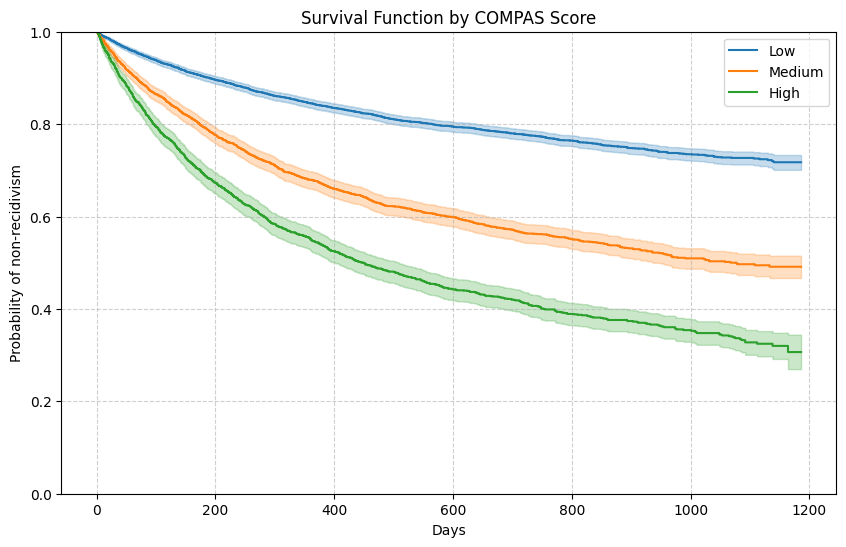

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

# Loop through each score and plot on the SAME axis
for score in ["Low", "Medium", "High"]:
    subset = data[data["score_factor"] == score]
    kmf.fit(durations=subset["end"], event_observed=subset["event"], entry=subset["start"], label=score)
    kmf.plot_survival_function(ci_show=True)

plt.title('Survival Function by COMPAS Score')
plt.xlabel('Days')
plt.ylabel('Probability of non-recidivism')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Given this dataset, Black defendants recidivate at higher rates according to race-specific Kaplan Meier plots.

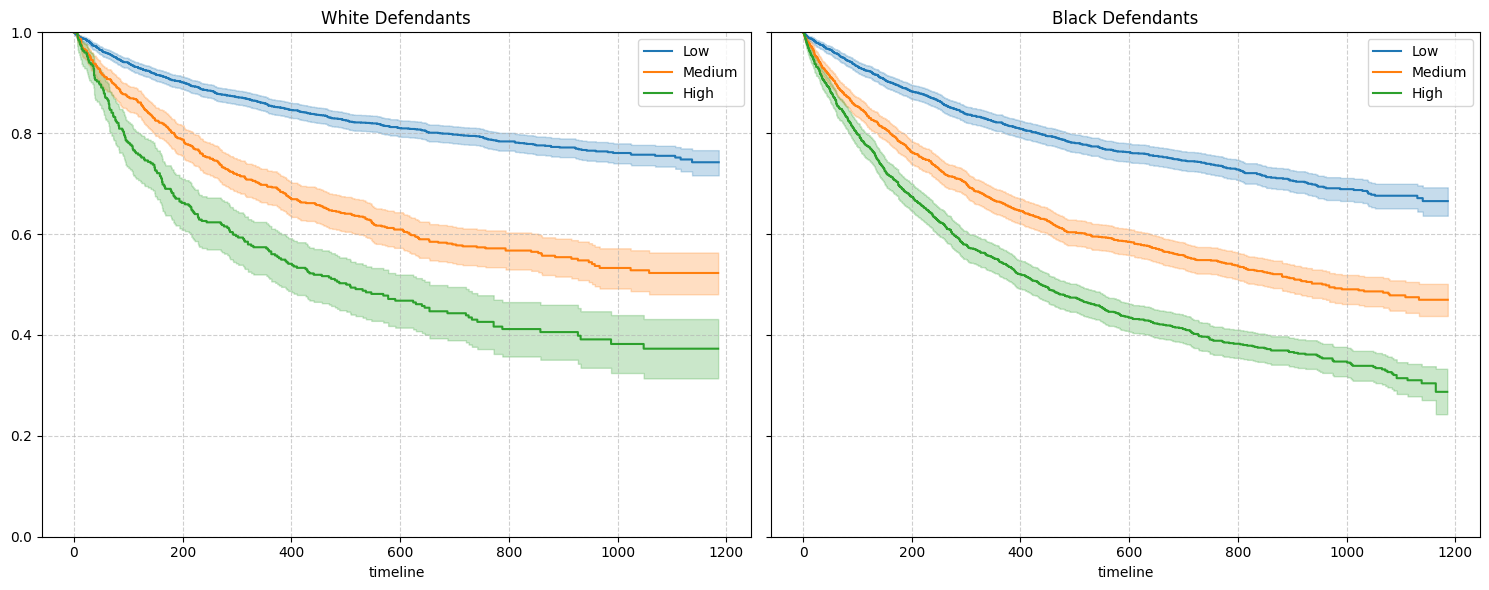

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

kmf = KaplanMeierFitter()
scores = ["Low", "Medium", "High"]

# White defendants
white_data = data[data['race'] == 'Caucasian']
for score in scores:
    subset = white_data[white_data['score_factor'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[0])
axes[0].set_title('White Defendants')
axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Black defendants
black_data = data[data['race'] == 'African-American']
for score in scores:
    subset = black_data[black_data['score_factor'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[1])
axes[1].set_title('Black Defendants')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = data[data["score_factor"] == score]

    # Fit survival curve
    kmf.fit(durations=subset["end"], event_observed=subset["event"], entry=subset["start"], label=score)

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = ci_730.iloc[0, 0]
    upper_730 = ci_730.iloc[0, 1]

    # Print results
    print(score)
    print("Overall Survival at 730 days:", survival_730)
    print("Lower 95% confidence interval:", lower_730)
    print("Upper 95% confidence interval:", upper_730)
    print()

Low
Overall Survival at 730 days: 0.7755366247831795
Lower 95% confidence interval: 0.7640552067102299
Upper 95% confidence interval: 0.7865401173081802

Medium
Overall Survival at 730 days: 0.5631474645020931
Lower 95% confidence interval: 0.5426808465853296
Upper 95% confidence interval: 0.5830771339209329

High
Overall Survival at 730 days: 0.4081472931419959
Lower 95% confidence interval: 0.3842331439131384
Upper 95% confidence interval: 0.4319005622636018



For the whole dataset, individuals in each group were this likely to "survive" or not be re-arrested in 730 days (two years):</br>
   77.5% low </br>
   56.3% medium</br>
   40.8% high

In [ ]:
# filtered to defendants identified as African-American
AA_data = data[data["race"] == "African-American"]

# Check each score group at time 730,

for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = AA_data[AA_data["score_factor"] == score]

    # Fit survival curve
    kmf.fit(durations=subset["end"], event_observed=subset["event"], entry=subset["start"], label=score)

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = ci_730.iloc[0, 0]
    upper_730 = ci_730.iloc[0, 1]

    # Print results
    print(score)
    print("African-American Survival at 730 days:", survival_730)
    print("Lower 95% confidence interval:", lower_730)
    print("Upper 95% confidence interval:", upper_730)
    print()

Low
African-American Survival at 730 days: 0.7430101314698092
Lower 95% confidence interval: 0.7234105111294775
Upper 95% confidence interval: 0.7614582234057639

Medium
African-American Survival at 730 days: 0.5484618451535137
Lower 95% confidence interval: 0.5217058389977448
Upper 95% confidence interval: 0.5743776469005313

High
African-American Survival at 730 days: 0.3976132414748815
Lower 95% confidence interval: 0.36969407026993195
Upper 95% confidence interval: 0.4253690324189963



For the African-American defendants in this dataset, individuals in each group were this likely to "survive" or not be re-arrested in 730 days (two years):</br>
   74.3% low </br>
   54.8% medium</br>
   39.8% high</br>
These numbers are slightly lower that the whole dataset. If the races were more evenly represented we would see these rates decrease as Black defendants (with disproportionately high COMPAS scores) are compared to more people of different races.

In [ ]:
# filtered to defendants identified as White
W_data = data[data["race"] == "Caucasian"]

# Check each score group at time 730,

for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = W_data[W_data["score_factor"] == score]

    # Fit survival curve
    kmf.fit(durations=subset["end"], event_observed=subset["event"], entry=subset["start"], label=score)

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = ci_730.iloc[0, 0]
    upper_730 = ci_730.iloc[0, 1]

    # Print results
    print(score)
    print("White Survival at 730 days:", survival_730)
    print("Lower 95% confidence interval:", lower_730)
    print("Upper 95% confidence interval:", upper_730)
    print()

Low
White Survival at 730 days: 0.7946073341971056
Lower 95% confidence interval: 0.7770771557605307
Upper 95% confidence interval: 0.8109312877713442

Medium
White Survival at 730 days: 0.575683295727647
Lower 95% confidence interval: 0.5384816958312129
Upper 95% confidence interval: 0.611033739916427

High
White Survival at 730 days: 0.43472948863102423
Lower 95% confidence interval: 0.3810011895777014
Upper 95% confidence interval: 0.4871685114025509



For the White defendants in this dataset, individuals in each group were this likely to "survive" or not be re-arrested in 730 days (two years):</br>
   79.5% low </br>
   57.6% medium</br>
   43.5% high</br>
These numbers are higher than the overall population in the dataset, for reasons already discussed.   

In [ ]:
kmf_AA = KaplanMeierFitter()
AA_data = data[data['race'] == 'African-American']
kmf_AA.fit(durations=AA_data['end'], event_observed=AA_data['event'], entry=AA_data['start'], label='African-American')
print(f"African-American defendants survival probability at 730 days: {kmf_AA.predict(730):.4f}")

African-American defendants survival probability at 730 days: 0.5955


In [ ]:
kmf_W = KaplanMeierFitter()
W_data = data[data['race'] == 'Caucasian']
kmf_W.fit(durations=W_data['end'], event_observed=W_data['event'], entry=W_data['start'], label='White')
print(f"White defendants survival probability at 730 days: {kmf_W.predict(730):.4f}")

White defendants survival probability at 730 days: 0.7097


Race specific models have similar concordance values.

In [ ]:
white_data = data[data['race'] == 'Caucasian']
white_cph = CoxPHFitter()
# Fix: Pass the white_data DataFrame, not the white_cph object itself
white_cph.fit(white_data[['start', 'end', 'event', 'decile_score']], entry_col='start', duration_col='end', event_col='event')
white_cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4572 total observations, 3548 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 4572
number of events observed = 1024
   partial log-likelihood = -7905.03
         time fit was run = 2026-03-30 10:52:55 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.20      1.22      0.01            0.18            0.22                1.20                1.25

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 18.36 <0.005    247.81
---
Concordance = 0.62
Partial AIC = 15812.07
log-likelihood ratio test = 313.00 on 1 df
-log2(p) of ll-ratio test = 230.26

In [ ]:
AA_data = data[data['race'] == 'African-American']
AA_cph = CoxPHFitter()
AA_cph.fit(AA_data[['start', 'end', 'event', 'decile_score']], entry_col='start', duration_col='end', event_col='event')
AA_cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6865 total observations, 4829 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 6865
number of events observed = 2036
   partial log-likelihood = -16274.23
         time fit was run = 2026-03-30 10:52:56 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.17      1.19      0.01            0.16            0.19                1.17                1.21

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 21.83 <0.005    348.51
---
Concordance = 0.60
Partial AIC = 32550.46
log-likelihood ratio test = 493.36 on 1 df
-log2(p) of ll-ratio test = 360.69

Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [ ]:
# Load and clean violent Cox data
url_v_cox = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
data_v_cox = pd.read_csv(url_v_cox)
data_v_cox = data_v_cox[(data_v_cox['score_text'] != 'N/A') & (data_v_cox['end'] > data_v_cox['start'])]

vcph = CoxPHFitter()
vcph.fit(data_v_cox[['start', 'end', 'event', 'v_decile_score']], entry_col='start', duration_col='end', event_col='event')
vcph.print_summary()

<lifelines.CoxPHFitter: fitted with 18200 total observations, 17382 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 18200
number of events observed = 818
   partial log-likelihood = -7233.93
         time fit was run = 2026-03-30 10:52:59 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
v_decile_score  0.23      1.26      0.01            0.20            0.25                1.23                1.29

                cmp to     z      p  -log2(p)
covariate                                    
v_decile_score    0.00 18.09 <0.005    240.62
---
Concordance = 0.62
Partial AIC = 14469.86
log-likelihood ratio test = 307.31 on 1 df
-log2(p) of ll-ratio test = 226.14

In this case, there isn't a significant coefficient on African American's with High Scores.

In [ ]:
# Violent Cox with interaction - Reverting to manual dummies to avoid IndexErrors with formula interface

# Ensure 'Caucasian' and 'Low' are the reference categories
data_v_cox['race'] = pd.Categorical(data_v_cox['race'], categories=['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'])
data_v_cox['score_text'] = pd.Categorical(data_v_cox['score_text'], categories=['Low', 'Medium', 'High'])

# Explicitly create dummies for the regression
data_v_interact = pd.get_dummies(data_v_cox[['start', 'end', 'event', 'race', 'score_text']], columns=['race', 'score_text'], drop_first=True)

# Identify columns for interaction calculation
af_am_col = 'race_African-American'
high_score_col = 'score_text_High'
med_score_col = 'score_text_Medium'

# Create interaction terms
data_v_interact['race_Black_High'] = data_v_interact[af_am_col] * data_v_interact[high_score_col]
data_v_interact['race_Black_Medium'] = data_v_interact[af_am_col] * data_v_interact[med_score_col]

vcph_interact = CoxPHFitter()
vcph_interact.fit(
    data_v_interact,
    entry_col='start',
    duration_col='end',
    event_col='event'
)

vcph_interact.print_summary()

<lifelines.CoxPHFitter: fitted with 18200 total observations, 17382 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 18200
number of events observed = 818
   partial log-likelihood = -7245.73
         time fit was run = 2026-03-30 10:53:04 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
race_African-American  0.29      1.34      0.13            0.04            0.55                1.04                1.73
race_Hispanic         -0.00      1.00      0.15           -0.29            0.29                0.74                1.34
race_Other             0.27      1.31      0.18           -0.08            0.62                0.92                1.85
race_Asian             0.37      1.44      0.50           -0.62            1.35                0.54                3.87
race_Native American   0.63      1.88      0.50           -0.36            1.62                0.70                5.06
score_text_Medium      0.76      2.14      0.13            0.50            1.02                1.65                2.77
score_text_High        1.49      4.45      0.14            1.22            1.77                3.38                5.87
race_Black_High       -0.25      0.78      0.18           -0.60            0.11                0.55                1.11
race_Black_Medium      0.00      1.00      0.18           -0.35            0.35                0.71                1.42

                       cmp to     z      p  -log2(p)
covariate                                           
race_African-American    0.00  2.27   0.02      5.44
race_Hispanic            0.00 -0.00   1.00      0.01
race_Other               0.00  1.52   0.13      2.95
race_Asian               0.00  0.72   0.47      1.09
race_Native American     0.00  1.25   0.21      2.25
score_text_Medium        0.00  5.72 <0.005     26.45
score_text_High          0.00 10.59 <0.005     84.58
race_Black_High          0.00 -1.37   0.17      2.55
race_Black_Medium        0.00  0.01   0.99      0.01
---
Concordance = 0.61
Partial AIC = 14509.46
log-likelihood ratio test = 283.71 on 9 df
-log2(p) of ll-ratio test = 183.14

In [ ]:
# Filter the data for African-American defendants
AA_violent_data = data_v_cox[data_v_cox['race'] == 'African-American']

# Initialize and fit the Cox model
cph_AA = CoxPHFitter()
cph_AA.fit(
    AA_violent_data[['start', 'end', 'event', 'v_decile_score']],
    entry_col='start',
    duration_col='end',
    event_col='event'
)

# Display the results
cph_AA.print_summary()

<lifelines.CoxPHFitter: fitted with 9723 total observations, 9228 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 9723
number of events observed = 495
   partial log-likelihood = -4032.53
         time fit was run = 2026-03-30 10:53:21 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
v_decile_score  0.21      1.23      0.02            0.17            0.24                1.19                1.27

                cmp to     z      p  -log2(p)
covariate                                    
v_decile_score    0.00 12.20 <0.005    111.26
---
Concordance = 0.60
Partial AIC = 8067.07
log-likelihood ratio test = 146.62 on 1 df
-log2(p) of ll-ratio test = 109.70

In [ ]:
# Filter the data for Caucasian defendants
white_violent_data = data_v_cox[data_v_cox['race'] == 'Caucasian']

# Initialize and fit the Cox model
cph_white_v = CoxPHFitter()
cph_white_v.fit(
    white_violent_data[['start', 'end', 'event', 'v_decile_score']],
    entry_col='start',
    duration_col='end',
    event_col='event'
)

# Display the results
cph_white_v.print_summary()

<lifelines.CoxPHFitter: fitted with 6051 total observations, 5830 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 6051
number of events observed = 221
   partial log-likelihood = -1742.96
         time fit was run = 2026-03-30 10:53:23 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
v_decile_score  0.22      1.24      0.03            0.17            0.27                1.18                1.31

                cmp to    z      p  -log2(p)
covariate                                   
v_decile_score    0.00 8.50 <0.005     55.54
---
Concordance = 0.61
Partial AIC = 3487.91
log-likelihood ratio test = 63.58 on 1 df
-log2(p) of ll-ratio test = 49.21

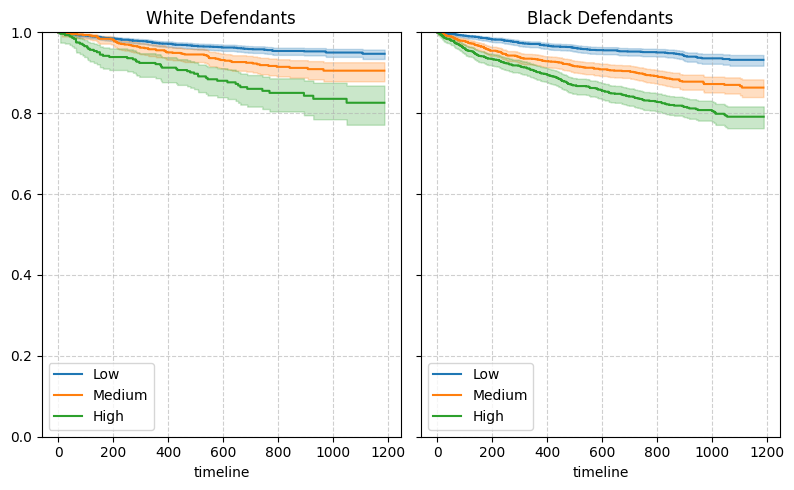

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

kmf = KaplanMeierFitter()
scores = ["Low", "Medium", "High"]

# White defendants
white_v = data_v_cox[data_v_cox['race'] == 'Caucasian']
for score in scores:
    subset = white_v[white_v['score_text'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[0])
axes[0].set_title('White Defendants')
axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Black defendants
black_v = data_v_cox[data_v_cox['race'] == 'African-American']
for score in scores:
    subset = black_v[black_v['score_text'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[1])
axes[1].set_title('Black Defendants')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [ ]:
# Filter the dataset to include only those who recidivated within 2 years
# or were followed for at least 2 years (730 days).
# We use the 'data' DataFrame which contains the unique individuals for this analysis.

# 1. Define the population for the truth table
pop = data[
    ((data['event'] == 1) & (data['end'] <= 730)) |
    (data['end'] > 730)
].copy()

# 2. Identify recidivists (event occurred within 2 years)
recid = pop[(pop['event'] == 1) & (pop['end'] <= 730)]

# 3. Identify non-recidivists (no event or event after 2 years)
surv = pop[~pop.index.isin(recid.index)]

print(f"Total population for truth table: {len(pop)}")
print(f"Recidivists: {len(recid)}")
print(f"Non-recidivists: {len(surv)}")

Total population for truth table: 7915
Recidivists: 3206
Non-recidivists: 4709


In [ ]:
def table(recid_df, surv_df):
    # Calculate counts for Recidivists (True Positives and False Negatives)
    tp = len(recid_df[recid_df['score_text'] != 'Low'])
    fn = len(recid_df[recid_df['score_text'] == 'Low'])

    # Calculate counts for Survived/Non-recidivists (False Positives and True Negatives)
    fp = len(surv_df[surv_df['score_text'] != 'Low'])
    tn = len(surv_df[surv_df['score_text'] == 'Low'])

    total = tp + fn + fp + tn

    print(f"Accuracy: {(tp + tn) / total:.2%}")
    print(f"False Positive Rate: {fp / (fp + tn):.2%}")
    print(f"False Negative Rate: {fn / (fn + tp):.2%}")
    print(f"Total Observations: {total:.2f}")

    # Return a formatted dataframe for visual display
    return pd.DataFrame([
        [tn, fp],
        [fn, tp]
    ], index=['Survived', 'Recidivated'], columns=['Low', 'High'])

# To match the classmate's output (Total 7214), we use raw_data
raw_recid = raw_data[raw_data['two_year_recid'] == 1]
raw_surv = raw_data[raw_data['two_year_recid'] == 0]

print("All defendants (Classmate Comparison)")
table(raw_recid, raw_surv)

All defendants (Classmate Comparison)
Accuracy: 65.37%
False Positive Rate: 32.35%
False Negative Rate: 37.40%
Total Observations: 7214.00


,Low,High
Survived,2681,1282
Recidivated,1216,2035


In [ ]:
print("Total pop: %i" % (2681 + 1282 + 1216 + 2035))

Total pop: 7214


In [ ]:
# Calculate followup time statistics using pandas
avg_followup = pop['end'].mean()
sd_followup = pop['end'].std()
median_followup = pop['end'].median()

print(f"Average followup time {avg_followup:.2f} (sd {sd_followup:.2f})")
print(f"Median followup time {int(median_followup)}")

Average followup time 667.37 (sd 385.47)
Median followup time 794


Overall, the false positive rate is 32.35%.

In [ ]:
print("Black defendants")

# ProPublica's specific logic for the truth table
# Filter for Black defendants from the raw dataset
df_black = raw_data[raw_data['race'] == 'African-American']

# Split based on the two_year_recid flag
recid_black = df_black[df_black['two_year_recid'] == 1]
surv_black = df_black[df_black['two_year_recid'] == 0]

table(recid_black, surv_black)

Black defendants
Accuracy: 63.83%
False Positive Rate: 44.85%
False Negative Rate: 27.99%
Total Observations: 3696.00


,Low,High
Survived,990,805
Recidivated,532,1369


That number is higher for African Americans at 44.85%.

In [ ]:
print("White defendants")

# Filter for White defendants from the raw dataset to match ProPublica's truth table logic
df_white = raw_data[raw_data['race'] == 'Caucasian']

# Split based on the two_year_recid flag
recid_white = df_white[df_white['two_year_recid'] == 1]
surv_white = df_white[df_white['two_year_recid'] == 0]

table(recid_white, surv_white)

White defendants
Accuracy: 66.99%
False Positive Rate: 23.45%
False Negative Rate: 47.72%
Total Observations: 2454.00


,Low,High
Survived,1139,349
Recidivated,461,505


And lower for whites at 23.45%.

In [ ]:
44.85 / 23.45

1.9125799573560769

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [ ]:
47.72 / 27.99

1.7048946052161487

In [ ]:
print("White defendants (Truth Table)")
table(recid_white, surv_white)

White defendants (Truth Table)
Accuracy: 66.99%
False Positive Rate: 23.45%
False Negative Rate: 47.72%
Total Observations: 2454.00


,Low,High
Survived,1139,349
Recidivated,461,505


In [ ]:
print("Black defendants (Truth Table)")
# Use the already defined df_black or recid_black/surv_black groups
table(recid_black, surv_black)

Black defendants (Truth Table)
Accuracy: 63.83%
False Positive Rate: 44.85%
False Negative Rate: 27.99%
Total Observations: 3696.00


,Low,High
Survived,990,805
Recidivated,532,1369


## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [ ]:
import pandas as pd

url_2yr = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url_2yr)

vpop = raw_data[
    (raw_data['days_b_screening_arrest'] <= 30) &
    (raw_data['days_b_screening_arrest'] >= -30) &
    (raw_data['v_score_text'].notna()) &
    (raw_data['v_score_text'] != 'N/A') &
    (raw_data['is_recid'] != -1) &
    (raw_data['c_charge_degree'] != 'O')
].copy()

vrecid = vpop[vpop['is_violent_recid'] == 1]
vsurv = vpop[vpop['is_violent_recid'] == 0]

print(f"Total population for violent truth table: {len(vpop)}")

Total population for violent truth table: 6172


In [ ]:
def vtable(recid_df, surv_df):
    # Calculate counts for Violent Recidivists (True Positives and False Negatives)
    tp = len(recid_df[recid_df['v_score_text'] != 'Low'])
    fn = len(recid_df[recid_df['v_score_text'] == 'Low'])

    # Calculate counts for Non-recidivists (False Positives and True Negatives)
    fp = len(surv_df[surv_df['v_score_text'] != 'Low'])
    tn = len(surv_df[surv_df['v_score_text'] == 'Low'])

    total = tp + fn + fp + tn
    print(f"Accuracy: {(tp + tn) / total:.2%}")
    print(f"False Positive Rate: {fp / (fp + tn):.2%}")
    print(f"False Negative Rate: {fn / (fn + tp):.2%}")

    return pd.DataFrame([[tn, fp], [fn, tp]], index=['Survived', 'Recidivated'], columns=['Low', 'High'])

print("All defendants (Violent)")
vtable(vrecid, vsurv)

All defendants (Violent)
Accuracy: 67.35%
False Positive Rate: 30.82%
False Negative Rate: 47.11%


,Low,High
Survived,3791,1689
Recidivated,326,366


Even moreso for Black defendants.

In [ ]:
print(f"Using vrecid with {len(vrecid)} individuals and vsurv with {len(vsurv)} individuals")

print("\nBlack defendants (Violent)")
vrecid_black = vrecid[vrecid['race'] == 'African-American']
vsurv_black = vsurv[vsurv['race'] == 'African-American']
vtable(vrecid_black, vsurv_black)

Using vrecid with 692 individuals and vsurv with 5480 individuals

Black defendants (Violent)
Accuracy: 59.37%
False Positive Rate: 40.92%
False Negative Rate: 38.73%


,Low,High
Survived,1624,1125
Recidivated,165,261


In [ ]:
print("White defendants (Violent)")
vrecid_white = vrecid[vrecid['race'] == 'Caucasian']
vsurv_white = vsurv[vsurv['race'] == 'Caucasian']
vtable(vrecid_white, vsurv_white)

White defendants (Violent)
Accuracy: 76.08%
False Positive Rate: 20.14%
False Negative Rate: 62.90%


,Low,High
Survived,1531,386
Recidivated,117,69


Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [ ]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [ ]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men. **The Kaplan Meier estimates will now correctly account for the entry time into the study.**

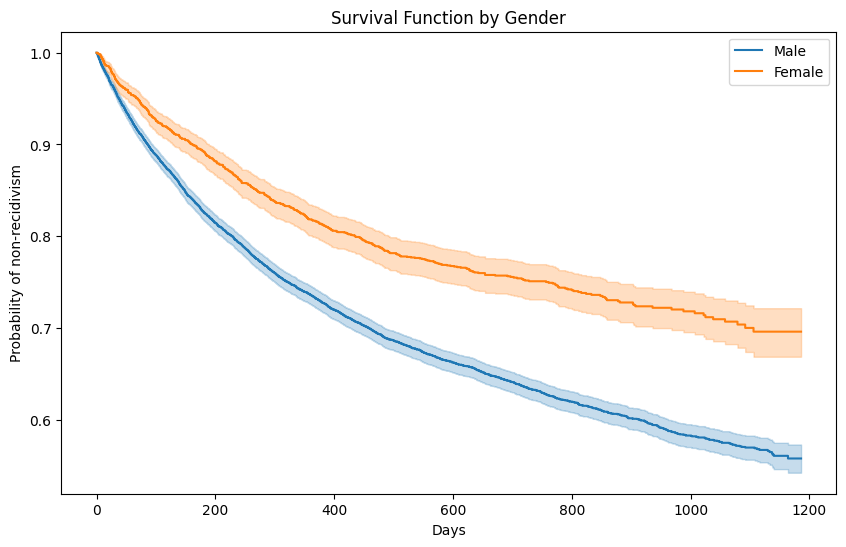

In [ ]:
from lifelines import KaplanMeierFitter

# Gender-specific Kaplan-Meier plots
kmf = KaplanMeierFitter()

male = data_cox[data_cox['sex'] == 'Male']
female = data_cox[data_cox['sex'] == 'Female']

plt.figure(figsize=(10, 6))

kmf.fit(durations=male['end'], event_observed=male['event'], entry=male['start'], label='Male')
ax = kmf.plot_survival_function()

kmf.fit(durations=female['end'], event_observed=female['event'], entry=female['start'], label='Female')
kmf.plot_survival_function(ax=ax)

plt.title('Survival Function by Gender')
plt.xlabel('Days')
plt.ylabel('Probability of non-recidivism')
plt.show()

In [ ]:
from lifelines import KaplanMeierFitter
kmf_m = KaplanMeierFitter()
male = data_cox[data_cox['sex'] == 'Male']
kmf_m.fit(durations=male['end'], event_observed=male['event'], entry=male['start'], label='Male')
survival_730_m = kmf_m.survival_function_at_times(730).values[0]
print(f"Male survival probability at 730 days: {survival_730_m:.4f}")

Male survival probability at 730 days: 0.6337


In [ ]:
kmf_f = KaplanMeierFitter()
female = data_cox[data_cox['sex'] == 'Female']
kmf_f.fit(durations=female['end'], event_observed=female['event'], entry=female['start'], label='Female')
survival_730_f = kmf_f.survival_function_at_times(730).values[0]
print(f"Female survival probability at 730 days: {survival_730_f:.4f}")

Female survival probability at 730 days: 0.7510


Again, this gender disparity may be due to demographic sample size in the training data.

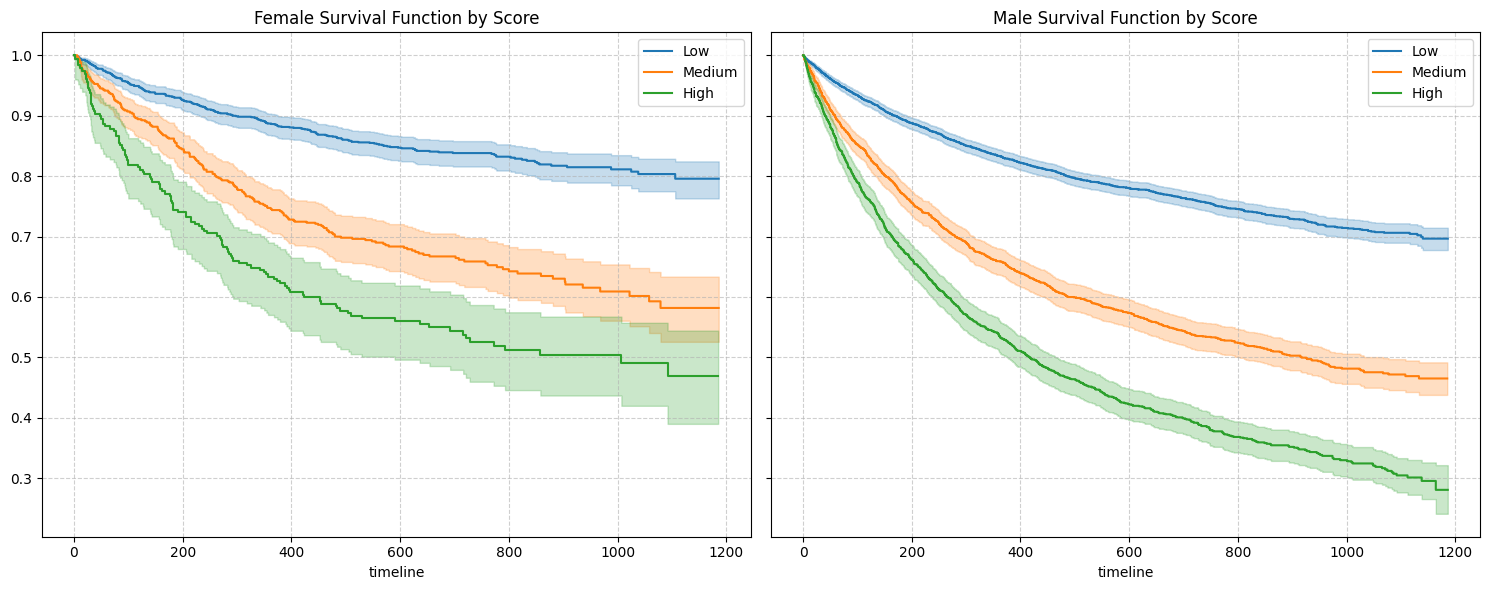

In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Initialize the fitter
kmf = KaplanMeierFitter()
scores = ['Low', 'Medium', 'High']

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot for Female Defendants (segmented by score)
female_data = data_cox[data_cox['sex'] == 'Female']
for score in scores:
    subset = female_data[female_data['score_text'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[0])
axes[0].set_title("Female Survival Function by Score")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot for Male Defendants (segmented by score)
male_data = data_cox[data_cox['sex'] == 'Male']
for score in scores:
    subset = male_data[male_data['score_text'] == score]
    if not subset.empty:
        kmf.fit(durations=subset['end'], event_observed=subset['event'], entry=subset['start'], label=score)
        kmf.plot_survival_function(ax=axes[1])
axes[1].set_title("Male Survival Function by Score")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

# Assignment 2

## Step 0 — Train / test split

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

# Define variables
features = ['two_year_recid', 'priors_count', 'age_factor', 'race_factor', 'gender_factor', 'crime_factor']
target = 'score_factor'

# X and y from the cleaned COMPAS cohort
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


## Step 1 — Fit logistic regression and gradient-boosted tree

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['two_year_recid', 'priors_count']
category_features = ['age_factor', 'race_factor', 'gender_factor', 'crime_factor']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['two_year_recid',
                                                   'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_factor', 'race_factor',
                                                   'gender_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Step 2 — Compare model performance by race

In [ ]:
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()
        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("--- Logistic Regression ---")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n--- Gradient-Boosted Tree ---")
print(group_metrics(gbt_pipeline, X_test, y_test))

--- Logistic Regression ---
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.732  0.211  0.346  0.791
2         Caucasian  404     0.767  0.515  0.099  0.812
3          Hispanic  110     0.773  0.690  0.062  0.780
5             Other   72     0.764  0.737  0.057  0.862
1             Asian    6     0.833  0.500  0.000  1.000
4   Native American    2     1.000  0.000  0.000  1.000

--- Gradient-Boosted Tree ---
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.730  0.247  0.301  0.790
2         Caucasian  404     0.755  0.485  0.131  0.799
3          Hispanic  110     0.827  0.414  0.086  0.806
5             Other   72     0.806  0.632  0.038  0.851
1             Asian    6     1.000  0.000  0.000  1.000
4   Native American    2     0.500  0.000  1.000  1.000


## Step 3 — LIME explanations: Black vs White defendant

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.transform(X_train)
if hasattr(X_train_enc, "toarray"): X_train_enc = X_train_enc.toarray()

feat_names = (numeric_features +
              list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)))

explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feat_names,
    class_names=["LowScore", "HighScore"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select a Black and White defendant for comparison
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_idx = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob").index[len(X_test_copy)//10]
white_idx = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob").index[len(X_test_copy)//10]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    if hasattr(row_enc, "toarray"): row_enc = row_enc.toarray()

    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability of HighScore: {X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability of HighScore: 0.127
 age_factor_Less than 25 > 0.00           -0.3490
 age_factor_Greater than 45 <= 0.00       -0.2037
 race_factor_Other <= 0.00                -0.1884
 0.00 < race_factor_African-American <= 1.00 -0.1176
 -0.92 < two_year_recid <= 1.09           -0.0847
 -0.47 < priors_count <= 0.17             +0.0827

 LIME: White defendant 
Predicted probability of HighScore: 0.596
 age_factor_Less than 25 <= 0.00          +0.3258
 age_factor_Greater than 45 <= 0.00       -0.2040
 race_factor_Other <= 0.00                -0.1491
 race_factor_African-American <= 0.00     +0.1177
 -0.47 < priors_count <= 0.17             +0.1056
 -0.92 < two_year_recid <= 1.09           -0.0949


## Step 4 — SHAP beeswarm and waterfall: Black vs White

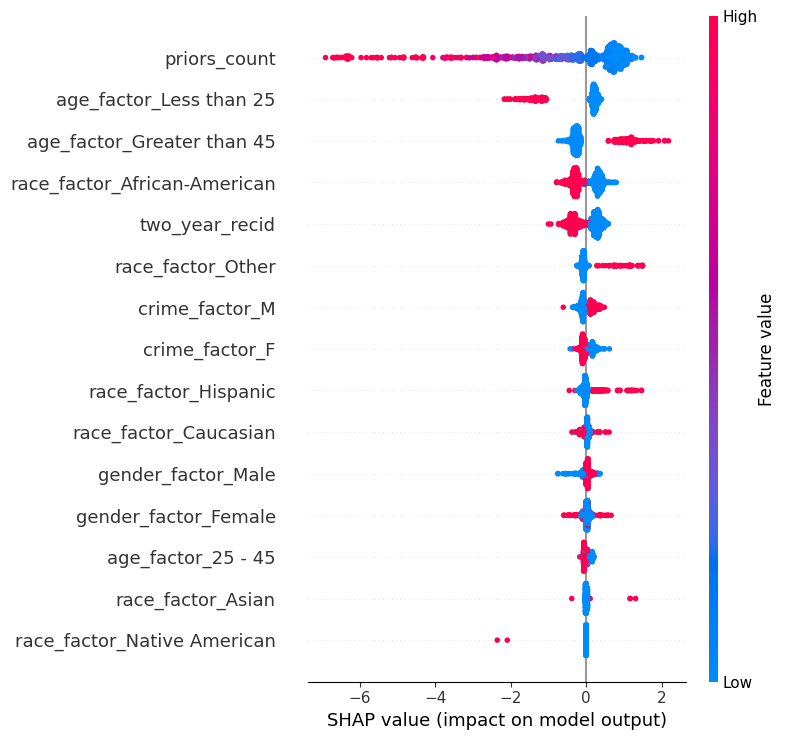

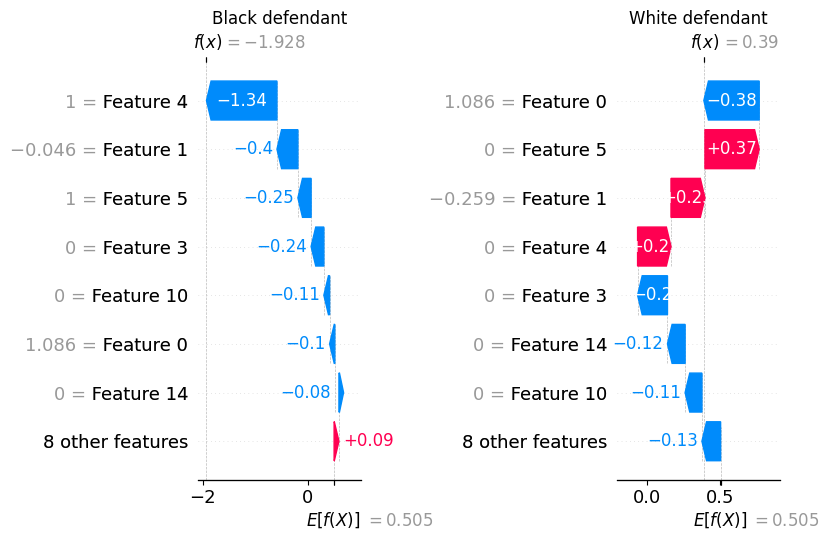

In [ ]:
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
if hasattr(X_test_enc, "toarray"): X_test_enc = X_test_enc.toarray()

feat_names = (numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(gbt_pipeline["classifier"], shap.maskers.Independent(X_test_enc, max_samples=100))
shap_values = explainer_shap(X_test_enc)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black vs White
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [(axes[0], black_loc, "Black defendant"), (axes[1], white_loc, "White defendant")]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

### Compare LIME and SHAP feature attributions

**Where do they agree?**
LIME and SHAP agree on how the most influential features affect their score. For example, prior criminal history increases the predicted score in both.

**Where do they diverge?**
LIME and SHAP diverge on how much to weight each feature. SHAP seems to weight the same feature(s) for people who look the same - more predictable. LIME is less consistent because it focuses more on each individual and the factors are not influential to a consistent magnitude.

**What does divergence imply for governance?**
SHAP's consistency allows for a closer look at consistent systemic patterns. LIME's sensitivity shows how each small change can change the prediction. This divergence indicates the model may not be predictive for certain subgroups. This is a big warning sign for the model's fairness and contestability.


## Step 5 — Counterfactuals with DiCE: Black vs White

These DiCE counterfactuals do not suggest any changes to race or gender (sex), only factors within their control like their criminal history. This ensures recommendations from the counterfactuals for improving one's COMPAS score are fair and allow recourse.

In [112]:
!pip install dice-ml -q
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(dataframe=pd.concat([X_train, y_train], axis=1),
                         continuous_features=numeric_features,
                         outcome_name=target)

dice_model = dice_ml.Model(model=gbt_pipeline, backend="sklearn", model_type="classifier")

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(query, total_CFs=3, desired_class="opposite",
                                           permitted_range={"priors_count": [0, 38]},
                                           features_to_vary=["priors_count", "two_year_recid"])
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00, 10.88it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : HighScore)


,two_year_recid,priors_count,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,1,3,Less than 25,African-American,Male,F,HighScore



Diverse Counterfactual set (new outcome: LowScore)


,two_year_recid,priors_count,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,0,0,-,-,-,-,LowScore


100%|██████████| 1/1 [00:00<00:00,  8.90it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : LowScore)


,two_year_recid,priors_count,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,1,2,25 - 45,Caucasian,Male,F,LowScore



Diverse Counterfactual set (new outcome: HighScore)


,two_year_recid,priors_count,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,-,15,-,-,-,-,HighScore
1,0,10,-,-,-,-,HighScore
2,0,12,-,-,-,-,HighScore
